# 02 - Data Quality Scoring: FDA Medical Device Master Data
## Project: Healthcare Device Master Data Governance
### Objective
Score the FDA 510(k) dataset across four core MDM data quality dimensions:
- **Completeness** — are all critical fields populated?
- **Uniqueness** — are there duplicate records?
- **Consistency** — are values standardized and uniform?
- **Validity** — are values in the correct format?

A composite Data Quality Score (DQS) will be calculated for each record.

In [1]:
# Import libraries and reload data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/Users/harshithasunkara/Documents/Projects/Healthcare MDM/data/raw/pmn96cur.txt',
                 sep='|',
                 encoding='latin-1',
                 low_memory=False)

print(f"Dataset loaded: {df.shape[0]:,} records, {df.shape[1]} columns")

Dataset loaded: 99,216 records, 22 columns


In [4]:
# See all columns with data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
df.head(3)

,KNUMBER,APPLICANT,CONTACT,STREET1,STREET2,CITY,STATE,COUNTRY_CODE,ZIP,POSTAL_CODE,DATERECEIVED,DECISIONDATE,DECISION,REVIEWADVISECOMM,PRODUCTCODE,STATEORSUMM,CLASSADVISECOMM,SSPINDICATOR,TYPE,THIRDPARTY,EXPEDITEDREVIEW,DEVICENAME
0,DEN000001,Ohmeda Medical,DANIEL KOSEDNAR,P.O. Box 7550,NaN,Madison,WI,US,53707,53707,01/07/2000,01/11/2000,DENG,AN,MRN,NaN,AN,NaN,Post-NSE,N,NaN,OHMEDA INOVENT DELIVERY SYSTEM
1,K000001,"Boston Scientific Scimed, Inc.",RON BENNETT,5905 Nathan Ln.,NaN,Plymouth,MN,US,55442,55442,01/03/2000,06/05/2000,SESE,SU,JCT,Summary,SU,NaN,Traditional,N,NaN,WALLGRAFT TRACHEOBRONCHIAL ENDOPROSTHESIS AND ...
2,DEN000002,"Urosurge, Inc.",STEVEN J PREISS,2660 Crosspark Rd.,NaN,Coralville,IA,US,52241,52241,01/27/2000,02/09/2000,DENG,GU,NAM,NaN,GU,NaN,Post-NSE,N,NaN,UROSURGE PERCUTANEOUS SANS (STOLLER AFFERENT N...


In [5]:
# Define critical MDM fields
critical_fields = ['KNUMBER', 'DEVICENAME', 'APPLICANT', 'DECISION', 
                   'DATERECEIVED', 'DECISIONDATE', 'PRODUCTCODE']

# ================================
# DIMENSION 1: COMPLETENESS SCORE
# ================================
print("=== DIMENSION 1: COMPLETENESS ===")

# Score each record - % of critical fields that are filled
df['COMPLETENESS_SCORE'] = df[critical_fields].notna().sum(axis=1) / len(critical_fields) * 100

print(f"Average Completeness Score: {df['COMPLETENESS_SCORE'].mean():.2f}%")
print(f"Records with 100% completeness: {(df['COMPLETENESS_SCORE'] == 100).sum():,}")
print(f"Records with < 80% completeness: {(df['COMPLETENESS_SCORE'] < 80).sum():,}")

=== DIMENSION 1: COMPLETENESS ===
Average Completeness Score: 100.00%
Records with 100% completeness: 99,206
Records with < 80% completeness: 0


In [6]:
# ================================
# DIMENSION 2: UNIQUENESS SCORE
# ================================
print("=== DIMENSION 2: UNIQUENESS ===")

# Flag duplicate KNUMBERs
df['IS_DUPLICATE_KNUMBER'] = df['KNUMBER'].duplicated(keep=False)

# Flag duplicate device names per applicant
df['IS_DUPLICATE_DEVICE'] = df.duplicated(
    subset=['DEVICENAME', 'APPLICANT'], keep=False)

# Uniqueness score - penalize duplicates
df['UNIQUENESS_SCORE'] = 100
df.loc[df['IS_DUPLICATE_KNUMBER'], 'UNIQUENESS_SCORE'] -= 50
df.loc[df['IS_DUPLICATE_DEVICE'], 'UNIQUENESS_SCORE'] -= 30

print(f"Duplicate KNUMBERs: {df['IS_DUPLICATE_KNUMBER'].sum():,}")
print(f"Duplicate DEVICENAME + APPLICANT combos: {df['IS_DUPLICATE_DEVICE'].sum():,}")
print(f"Average Uniqueness Score: {df['UNIQUENESS_SCORE'].mean():.2f}%")

=== DIMENSION 2: UNIQUENESS ===
Duplicate KNUMBERs: 0
Duplicate DEVICENAME + APPLICANT combos: 9,947
Average Uniqueness Score: 96.99%


In [11]:
print("=== ALL UNIQUE DECISION CODES ===")
print(df['DECISION'].value_counts())

=== ALL UNIQUE DECISION CODES ===
DECISION
SESE    97572
DENG      471
SESU      434
SN        307
SESK      235
ST        152
SEKD       23
SESD       10
PT          9
SESP        3
Name: count, dtype: int64


In [9]:
# ================================
# DIMENSION 3: CONSISTENCY SCORE
# ================================
print("=== DIMENSION 3: CONSISTENCY ===")

# Check 1: APPLICANT name formatting issues
df['APPLICANT_UPPER'] = df['APPLICANT'].str.isupper()
df['APPLICANT_LOWER'] = df['APPLICANT'].str.islower()
df['APPLICANT_HAS_NUMBERS'] = df['APPLICANT'].str.contains(r'\d', na=False)

# Check 2: DECISION values should only be known valid codes
valid_decisions = ['SESE', 'DENG', 'SESU', 'SN', 'SESK', 
                   'ST', 'SEKD', 'SESD', 'PT', 'SESP']
df['INVALID_DECISION'] = ~df['DECISION'].isin(valid_decisions)

# Check 3: Date consistency - DECISIONDATE should be after DATERECEIVED
df['DATERECEIVED'] = pd.to_datetime(df['DATERECEIVED'], errors='coerce')
df['DECISIONDATE'] = pd.to_datetime(df['DECISIONDATE'], errors='coerce')
df['INVALID_DATE_ORDER'] = df['DECISIONDATE'] < df['DATERECEIVED']

# Consistency score
df['CONSISTENCY_SCORE'] = 100
df.loc[df['APPLICANT_UPPER'], 'CONSISTENCY_SCORE'] -= 10
df.loc[df['APPLICANT_LOWER'], 'CONSISTENCY_SCORE'] -= 10
df.loc[df['APPLICANT_HAS_NUMBERS'], 'CONSISTENCY_SCORE'] -= 10
df.loc[df['INVALID_DECISION'], 'CONSISTENCY_SCORE'] -= 30
df.loc[df['INVALID_DATE_ORDER'], 'CONSISTENCY_SCORE'] -= 40

print(f"ALL CAPS applicant names: {df['APPLICANT_UPPER'].sum():,}")
print(f"all lowercase applicant names: {df['APPLICANT_LOWER'].sum():,}")
print(f"Applicants with numbers: {df['APPLICANT_HAS_NUMBERS'].sum():,}")
print(f"Invalid DECISION codes: {df['INVALID_DECISION'].sum():,}")
print(f"Invalid date order: {df['INVALID_DATE_ORDER'].sum():,}")
print(f"\nAverage Consistency Score: {df['CONSISTENCY_SCORE'].mean():.2f}%")

=== DIMENSION 3: CONSISTENCY ===
ALL CAPS applicant names: 186
all lowercase applicant names: 0
Applicants with numbers: 1,328
Invalid DECISION codes: 0
Invalid date order: 0

Average Consistency Score: 99.85%


=== ALL UNIQUE DECISION CODES ===
DECISION
SESE    97572
DENG      471
SESU      434
SN        307
SESK      235
ST        152
SEKD       23
SESD       10
PT          9
SESP        3
Name: count, dtype: int64


In [10]:
# Check actual date range in dataset
print("=== ACTUAL DATE RANGE IN DATASET ===")
print(f"Earliest DATERECEIVED: {df['DATERECEIVED'].min()}")
print(f"Latest DATERECEIVED: {df['DATERECEIVED'].max()}")
print(f"Earliest DECISIONDATE: {df['DECISIONDATE'].min()}")
print(f"Latest DECISIONDATE: {df['DECISIONDATE'].max()}")

=== ACTUAL DATE RANGE IN DATASET ===
Earliest DATERECEIVED: 1991-11-27 00:00:00
Latest DATERECEIVED: 2026-03-20 00:00:00
Earliest DECISIONDATE: 1996-01-02 00:00:00
Latest DECISIONDATE: 2026-04-10 00:00:00


In [12]:
# ================================
# DIMENSION 4: VALIDITY SCORE
# ================================
print("=== DIMENSION 4: VALIDITY ===")

# Check 1: KNUMBER format should start with K or DEN
df['INVALID_KNUMBER_FORMAT'] = ~df['KNUMBER'].str.match(r'^(K|DEN)\d+', na=False)

# Check 2: DEVICENAME should not be just numbers
df['INVALID_DEVICENAME'] = df['DEVICENAME'].str.match(r'^\d+$', na=False)

# Check 3: DATERECEIVED should be within reasonable range
df['INVALID_DATE_RANGE'] = (
    (df['DATERECEIVED'].dt.year < 1991) | 
    (df['DATERECEIVED'].dt.year > 2026)
)

# Validity score
df['VALIDITY_SCORE'] = 100
df.loc[df['INVALID_KNUMBER_FORMAT'], 'VALIDITY_SCORE'] -= 50
df.loc[df['INVALID_DEVICENAME'], 'VALIDITY_SCORE'] -= 30
df.loc[df['INVALID_DATE_RANGE'], 'VALIDITY_SCORE'] -= 20

print(f"Invalid KNUMBER formats: {df['INVALID_KNUMBER_FORMAT'].sum():,}")
print(f"Invalid DEVICENAME (numbers only): {df['INVALID_DEVICENAME'].sum():,}")
print(f"Invalid date ranges: {df['INVALID_DATE_RANGE'].sum():,}")
print(f"\nAverage Validity Score: {df['VALIDITY_SCORE'].mean():.2f}%")

=== DIMENSION 4: VALIDITY ===
Invalid KNUMBER formats: 0
Invalid DEVICENAME (numbers only): 2
Invalid date ranges: 0

Average Validity Score: 100.00%


In [13]:
# ================================
# COMPOSITE DATA QUALITY SCORE
# ================================
print("=== COMPOSITE DATA QUALITY SCORE (DQS) ===")

# Weighted average of all 4 dimensions
df['DQS'] = (
    df['COMPLETENESS_SCORE'] * 0.30 +
    df['UNIQUENESS_SCORE'] * 0.30 +
    df['CONSISTENCY_SCORE'] * 0.25 +
    df['VALIDITY_SCORE'] * 0.15
)

print(f"Average Data Quality Score: {df['DQS'].mean():.2f}%")
print(f"Records scoring 100%: {(df['DQS'] == 100).sum():,}")
print(f"Records scoring >= 90%: {(df['DQS'] >= 90).sum():,}")
print(f"Records scoring < 80%: {(df['DQS'] < 80).sum():,}")
print(f"Records scoring < 70%: {(df['DQS'] < 70).sum():,}")

print(f"\n=== DQS DISTRIBUTION ===")
print(df['DQS'].describe())

=== COMPOSITE DATA QUALITY SCORE (DQS) ===
Average Data Quality Score: 99.06%
Records scoring 100%: 88,005
Records scoring >= 90%: 98,981
Records scoring < 80%: 0
Records scoring < 70%: 0

=== DQS DISTRIBUTION ===
count    99216.000000
mean        99.059024
std          2.728364
min         86.714286
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: DQS, dtype: float64


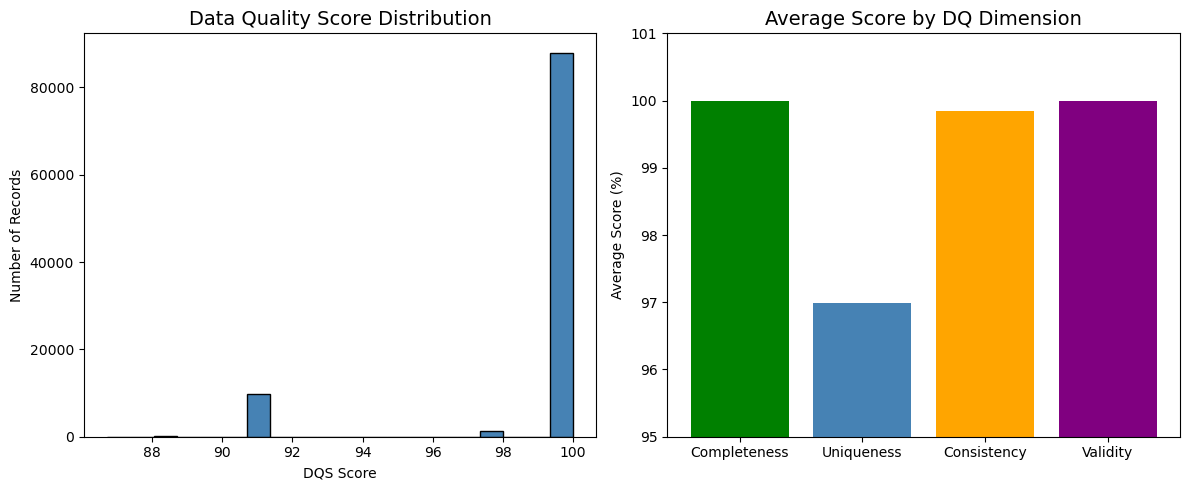

Chart saved to reports folder!


In [14]:
# ================================
# DATA QUALITY SCORE VISUALIZATION
# ================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: DQS Distribution
axes[0].hist(df['DQS'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Data Quality Score Distribution', fontsize=14)
axes[0].set_xlabel('DQS Score')
axes[0].set_ylabel('Number of Records')

# Plot 2: Average score by dimension
dimensions = ['Completeness', 'Uniqueness', 'Consistency', 'Validity']
scores = [
    df['COMPLETENESS_SCORE'].mean(),
    df['UNIQUENESS_SCORE'].mean(),
    df['CONSISTENCY_SCORE'].mean(),
    df['VALIDITY_SCORE'].mean()
]

axes[1].bar(dimensions, scores, color=['green', 'steelblue', 'orange', 'purple'])
axes[1].set_title('Average Score by DQ Dimension', fontsize=14)
axes[1].set_ylabel('Average Score (%)')
axes[1].set_ylim(95, 101)

plt.tight_layout()
plt.savefig('../reports/data_quality_scores.png')
plt.show()
print("Chart saved to reports folder!")